In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ============================================================
# IMAGE-TO-IMAGE RAG FOR FASHION
# Improved Pipeline with Color + Category-Aware Search
# ============================================================

# ============================================================
# CELL 1: Install Dependencies
# ============================================================
!pip install git+https://github.com/openai/CLIP.git
!pip install faiss-cpu pillow numpy torch torchvision sentence-transformers

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-26kthq20
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-26kthq20
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=81c2650261ac992feab7cbfac34e0c3975a58a2a0df12c358f4082cee0f02739
  Stored in directory: /tmp/pip-ephem-wheel-cache-585ha8u_/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.8 MB/s eta 0:00:00:00:0100:01


In [2]:
# ============================================================
# CELL 2: Imports & Device Setup
# ============================================================
import os
import json
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
import clip
import faiss

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load CLIP model (ViT-B/32 is a good balance of speed and accuracy)
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

Using device: cuda


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 95.9MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [3]:
# ============================================================
# CELL 3: Color Extraction using CLIP Zero-Shot Classification
# Instead of a basic color histogram (which is noisy), we use
# CLIP itself to classify the dominant clothing color — this
# is more robust for fashion images with complex backgrounds.
# ============================================================

COLOR_LABELS = [
    "red", "blue", "green", "yellow", "orange", "purple",
    "pink", "white", "black", "grey", "brown", "beige",
    "navy", "teal", "maroon", "olive", "cream", "gold", "silver"
]

CATEGORY_LABELS = [
    "t-shirt", "dress", "jeans", "trousers", "shirt", "jacket",
    "coat", "skirt", "shorts", "hoodie", "sweater", "blouse",
    "suit", "activewear", "swimwear", "top", "pants", "cardigan"
]

STYLE_LABELS = [
    "casual", "formal", "sporty", "elegant", "streetwear",
    "vintage", "bohemian", "minimalist", "oversized", "fitted"
]

def classify_with_clip(image_tensor, label_list, top_k=1):
    """
    Zero-shot classify an image against a list of text labels using CLIP.
    Returns top_k (label, score) tuples.
    """
    text_tokens = clip.tokenize([f"a photo of a {l}" for l in label_list]).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image_tensor)
        text_features = model.encode_text(text_tokens)

        # Normalize both for cosine similarity
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Cosine similarity scores
        similarity = (image_features @ text_features.T).squeeze(0)
        probs = similarity.softmax(dim=-1).cpu().numpy()

    top_indices = probs.argsort()[::-1][:top_k]
    return [(label_list[i], float(probs[i])) for i in top_indices]


def extract_metadata(image_tensor):
    """
    Extract color, category, and style metadata for a single image tensor.
    Returns a dict with top predictions and their confidence scores.
    """
    color_results   = classify_with_clip(image_tensor, COLOR_LABELS,    top_k=3)
    category_results = classify_with_clip(image_tensor, CATEGORY_LABELS, top_k=2)
    style_results   = classify_with_clip(image_tensor, STYLE_LABELS,    top_k=2)

    return {
        "top_color":      color_results[0][0],
        "color_scores":   {r[0]: r[1] for r in color_results},
        "top_category":   category_results[0][0],
        "category_scores": {r[0]: r[1] for r in category_results},
        "top_style":      style_results[0][0],
        "style_scores":   {r[0]: r[1] for r in style_results},
    }

In [4]:
# ============================================================
# CELL 4: Dataset Indexing
# Encodes every image into:
#   (a) a CLIP visual embedding  → stored in FAISS
#   (b) metadata dict (color, category, style) → stored in a list
# ============================================================

dataset_root = "/kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images"  # <-- change this

# Gather all image paths
image_paths = []
for dirpath, _, filenames in os.walk(dataset_root):
    for f in filenames:
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp")):
            image_paths.append(os.path.join(dirpath, f))

print(f"Found {len(image_paths)} images.")

# Storage
all_embeddings = []
all_metadata   = []   # list of dicts, one per image
valid_paths    = []

BATCH_SIZE = 32  # lower if you run out of GPU memory

for i in range(0, len(image_paths), BATCH_SIZE):
    batch_paths = image_paths[i : i + BATCH_SIZE]
    batch_tensors = []

    for path in batch_paths:
        try:
            img = preprocess(Image.open(path).convert("RGB"))
            batch_tensors.append(img)
        except Exception as e:
            print(f"Skipping {path}: {e}")
            continue

    if not batch_tensors:
        continue

    batch_tensor = torch.stack(batch_tensors).to(device)

    # --- (a) Visual embeddings ---
    with torch.no_grad():
        emb = model.encode_image(batch_tensor)
        emb = emb / emb.norm(dim=-1, keepdim=True)  # L2 normalize

    all_embeddings.append(emb.cpu().numpy())

    # --- (b) Metadata (process one-by-one since CLIP classifier is per-image) ---
    for j, tensor in enumerate(batch_tensors):
        meta = extract_metadata(tensor.unsqueeze(0).to(device))
        all_metadata.append(meta)

    valid_paths.extend(batch_paths[:len(batch_tensors)])

    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  Processed {i + len(batch_tensors)}/{len(image_paths)}...")

# Stack all embeddings into a single numpy array
all_embeddings = np.vstack(all_embeddings).astype("float32")
print(f"\nDone. Encoded {len(valid_paths)} images.")
print(f"Embedding matrix shape: {all_embeddings.shape}")

Found 10335 images.
  Processed 32/10335...
  Processed 352/10335...
  Processed 672/10335...
  Processed 992/10335...
  Processed 1312/10335...
  Processed 1632/10335...
  Processed 1952/10335...
  Processed 2272/10335...
  Processed 2592/10335...
  Processed 2912/10335...
  Processed 3232/10335...
  Processed 3552/10335...
  Processed 3872/10335...
  Processed 4192/10335...
  Processed 4512/10335...
  Processed 4832/10335...
  Processed 5152/10335...
  Processed 5472/10335...
  Processed 5792/10335...
  Processed 6112/10335...
  Processed 6432/10335...
  Processed 6752/10335...
  Processed 7072/10335...
  Processed 7392/10335...
  Processed 7712/10335...
  Processed 8032/10335...
  Processed 8352/10335...
  Processed 8672/10335...
  Processed 8992/10335...
  Processed 9312/10335...
  Processed 9632/10335...
  Processed 9952/10335...
  Processed 10272/10335...

Done. Encoded 10335 images.
Embedding matrix shape: (10335, 512)


In [5]:
# ============================================================
# CELL 5: Build FAISS Index
# We use IndexFlatIP (inner product = cosine sim on normalized vecs)
# For very large datasets (>100k), swap to IndexIVFFlat for speed.
# ============================================================

dim = all_embeddings.shape[1]  # 512 for ViT-B/32

index = faiss.IndexFlatIP(dim)
index.add(all_embeddings)

print(f"FAISS index built with {index.ntotal} vectors.")

FAISS index built with 10335 vectors.


In [6]:
# ============================================================
# CELL 6: Save Index + Metadata to Disk
# So you don't have to re-encode everything on restart.
# ============================================================

SAVE_DIR = "/kaggle/working/"
os.makedirs(SAVE_DIR, exist_ok=True)

faiss.write_index(index, os.path.join(SAVE_DIR, "faiss.index"))

with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump({
        "paths":    valid_paths,
        "metadata": all_metadata
    }, f, indent=2)

print(f"Index saved to {SAVE_DIR}/")

Index saved to ./fashion_rag_index/


In [7]:
# ============================================================
# CELL 7: Load Index (run this instead of cells 4-6 on restart)
# ============================================================

SAVE_DIR = "/kaggle/working/"

index = faiss.read_index(os.path.join(SAVE_DIR, "faiss.index"))

with open(os.path.join(SAVE_DIR, "metadata.json"), "r") as f:
    saved = json.load(f)

valid_paths  = saved["paths"]
all_metadata = saved["metadata"]

print(f"Loaded index with {index.ntotal} vectors and {len(valid_paths)} paths.")

Loaded index with 10335 vectors and 10335 paths.


In [8]:
# ============================================================
# CELL 8: Metadata Filtering Helper
#
# This is the KEY improvement over the original code.
# After CLIP retrieves the top-N visual neighbors, we FILTER
# them by color/category/style so blue dresses don't appear
# when you search for a red dress.
#
# Strategy: retrieve more candidates (k * retrieval_multiplier),
# then hard-filter by metadata, then return top k.
# ============================================================

def metadata_score(query_meta, candidate_meta, weights=None):
    """
    Compute a metadata compatibility score between query and candidate.
    Higher = more similar attributes.

    weights: dict controlling how much each attribute matters.
    Default: color matters most for fashion.
    """
    if weights is None:
        weights = {"color": 0.6, "category": 0.3, "style": 0.1}

    score = 0.0

    # Color match: use soft score (similarity of color distributions)
    q_colors = query_meta.get("color_scores", {})
    c_colors = candidate_meta.get("color_scores", {})
    for color, q_score in q_colors.items():
        score += weights["color"] * q_score * c_colors.get(color, 0.0)

    # Category match
    q_cats = query_meta.get("category_scores", {})
    c_cats = candidate_meta.get("category_scores", {})
    for cat, q_score in q_cats.items():
        score += weights["category"] * q_score * c_cats.get(cat, 0.0)

    # Style match
    q_styles = query_meta.get("style_scores", {})
    c_styles = candidate_meta.get("style_scores", {})
    for style, q_score in q_styles.items():
        score += weights["style"] * q_score * c_styles.get(style, 0.0)

    return score


def combined_score(clip_similarity, meta_score, alpha=0.6):
    """
    Final ranking score = weighted combination of:
      - CLIP visual similarity  (captures texture, shape, overall look)
      - Metadata attribute score (captures color, category, style explicitly)

    alpha: weight for CLIP score (1-alpha goes to metadata)
    """
    return alpha * clip_similarity + (1 - alpha) * meta_score

In [9]:
# ============================================================
# CELL 9: Image Query Function (the main search)
# ============================================================

def search_by_image(
    query_image_path,
    k=5,
    retrieval_multiplier=10,
    alpha=0.6,
    filter_by_color=True,
    filter_by_category=False,
    verbose=True
):
    """
    Search for similar fashion images using a query image.

    Args:
        query_image_path:     Path to the query image.
        k:                    Number of final results to return.
        retrieval_multiplier: How many extra candidates to fetch before filtering.
                              Higher = better recall, slower.
        alpha:                Weight of CLIP score vs metadata score (0-1).
        filter_by_color:      Hard-filter results to match query color.
        filter_by_category:   Hard-filter results to match query category.
        verbose:              Print results.
    """
    # --- Encode query image ---
    try:
        query_tensor = preprocess(Image.open(query_image_path).convert("RGB")).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Error loading query image: {e}")
        return []

    with torch.no_grad():
        query_emb = model.encode_image(query_tensor)
        query_emb = query_emb / query_emb.norm(dim=-1, keepdim=True)

    query_emb_np = query_emb.cpu().numpy().astype("float32")

    # --- Extract query metadata ---
    query_meta = extract_metadata(query_tensor)
    if verbose:
        print(f"\nQuery Image: {query_image_path}")
        print(f"  Detected color:    {query_meta['top_color']}")
        print(f"  Detected category: {query_meta['top_category']}")
        print(f"  Detected style:    {query_meta['top_style']}")

    # --- FAISS retrieval (over-fetch for post-filtering) ---
    n_retrieve = min(k * retrieval_multiplier, index.ntotal)
    clip_scores, indices = index.search(query_emb_np, n_retrieve)
    clip_scores = clip_scores[0]
    indices     = indices[0]

    # --- Post-filter + re-rank by metadata ---
    candidates = []
    for rank, (idx, clip_sim) in enumerate(zip(indices, clip_scores)):
        if idx < 0 or idx >= len(valid_paths):
            continue

        cand_meta = all_metadata[idx]

        # Hard color filter: skip if top color doesn't match query color
        if filter_by_color and cand_meta["top_color"] != query_meta["top_color"]:
            continue

        # Hard category filter (optional)
        if filter_by_category and cand_meta["top_category"] != query_meta["top_category"]:
            continue

        # Compute soft metadata score
        meta_s = metadata_score(query_meta, cand_meta)

        # Final combined score
        final_score = combined_score(float(clip_sim), meta_s, alpha=alpha)

        candidates.append({
            "path":        valid_paths[idx],
            "clip_score":  float(clip_sim),
            "meta_score":  meta_s,
            "final_score": final_score,
            "metadata":    cand_meta
        })

    # Sort by combined score descending
    candidates.sort(key=lambda x: x["final_score"], reverse=True)
    results = candidates[:k]

    if verbose:
        print(f"\nTop {len(results)} results:")
        for i, r in enumerate(results):
            print(f"  {i+1}. {r['path']}")
            print(f"     CLIP: {r['clip_score']:.3f} | Meta: {r['meta_score']:.3f} | Final: {r['final_score']:.3f}")
            print(f"     Color: {r['metadata']['top_color']} | Category: {r['metadata']['top_category']}")

    return results

In [10]:
# ============================================================
# CELL 10: Text Query Function
# Encodes a natural language description and searches the index.
# e.g. "girl in red dress", "white oversized t-shirt"
# ============================================================

def search_by_text(
    text_query,
    k=5,
    retrieval_multiplier=10,
    alpha=0.5,
    verbose=True
):
    """
    Search the fashion index using a natural language text query.
    Text is embedded with CLIP and matched against image embeddings.
    Metadata is inferred from the query text itself via zero-shot classification.
    """
    # --- Encode text query ---
    text_tokens = clip.tokenize([text_query]).to(device)

    with torch.no_grad():
        text_emb = model.encode_text(text_tokens)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)

    text_emb_np = text_emb.cpu().numpy().astype("float32")

    # --- Infer query metadata by checking which labels the text matches ---
    # We simulate what the image would look like by classifying the text itself
    text_label_tokens = clip.tokenize([f"a photo of a {l}" for l in COLOR_LABELS]).to(device)
    with torch.no_grad():
        text_label_emb = model.encode_text(text_label_tokens)
        text_label_emb = text_label_emb / text_label_emb.norm(dim=-1, keepdim=True)
        color_sim = (text_emb @ text_label_emb.T).squeeze(0).softmax(dim=-1).cpu().numpy()

    top_color_idx = color_sim.argsort()[::-1][:3]
    query_meta = {
        "color_scores":    {COLOR_LABELS[i]: float(color_sim[i]) for i in top_color_idx},
        "top_color":       COLOR_LABELS[top_color_idx[0]],
        "category_scores": {},  # can extend similarly for categories
        "top_category":    "",
        "style_scores":    {},
        "top_style":       ""
    }

    if verbose:
        print(f"\nText Query: '{text_query}'")
        print(f"  Inferred color: {query_meta['top_color']}")

    # --- FAISS retrieval ---
    n_retrieve = min(k * retrieval_multiplier, index.ntotal)
    clip_scores, indices = index.search(text_emb_np, n_retrieve)
    clip_scores = clip_scores[0]
    indices     = indices[0]

    # --- Re-rank by metadata ---
    candidates = []
    for idx, clip_sim in zip(indices, clip_scores):
        if idx < 0 or idx >= len(valid_paths):
            continue

        cand_meta = all_metadata[idx]
        meta_s    = metadata_score(query_meta, cand_meta, weights={"color": 0.8, "category": 0.15, "style": 0.05})
        final_score = combined_score(float(clip_sim), meta_s, alpha=alpha)

        candidates.append({
            "path":        valid_paths[idx],
            "clip_score":  float(clip_sim),
            "meta_score":  meta_s,
            "final_score": final_score,
            "metadata":    cand_meta
        })

    candidates.sort(key=lambda x: x["final_score"], reverse=True)
    results = candidates[:k]

    if verbose:
        print(f"\nTop {len(results)} results:")
        for i, r in enumerate(results):
            print(f"  {i+1}. {r['path']}")
            print(f"     CLIP: {r['clip_score']:.3f} | Meta: {r['meta_score']:.3f} | Final: {r['final_score']:.3f}")
            print(f"     Color: {r['metadata']['top_color']} | Category: {r['metadata']['top_category']}")

    return results


Query Image: /kaggle/input/datasets/abulkashemjunaid/lungipic/Amanat_Shah_lungi_LS-1141_121_1.jpg
  Detected color:    brown
  Detected category: trousers
  Detected style:    oversized

Top 5 results:
  1. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/MEN-Sweaters-id_00004348-04_7_additional.png
     CLIP: 0.755 | Meta: 0.004 | Final: 0.455
     Color: brown | Category: shorts
  2. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/MEN-Sweaters-id_00004959-03_4_full.png
     CLIP: 0.729 | Meta: 0.005 | Final: 0.439
     Color: brown | Category: trousers
  3. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/MEN-Pants-id_00001468-04_7_additional.png
     CLIP: 0.727 | Meta: 0.004 | Final: 0.438
     Color: brown | Category: trousers
  4. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/MEN-Shorts-id_00001082-01_7_additional.png
     CLIP: 0.725 | Meta: 0.006 | Final: 0.437
     Colo

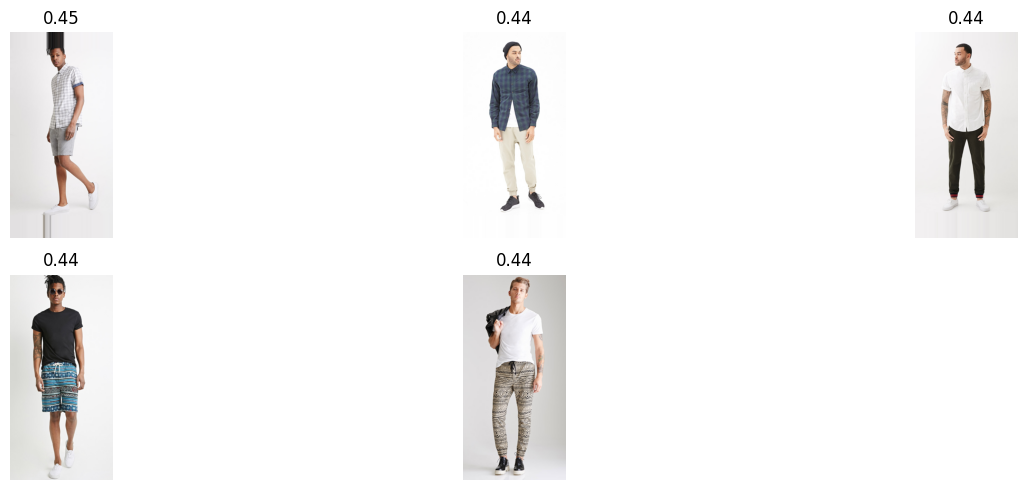


Text Query: 'girl wearing white dress'
  Inferred color: white

Top 5 results:
  1. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/WOMEN-Dresses-id_00004733-02_7_additional.png
     CLIP: 0.308 | Meta: 0.005 | Final: 0.157
     Color: white | Category: dress
  2. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/WOMEN-Dresses-id_00007109-02_2_side.png
     CLIP: 0.303 | Meta: 0.005 | Final: 0.154
     Color: white | Category: dress
  3. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/WOMEN-Dresses-id_00000301-03_4_full.png
     CLIP: 0.298 | Meta: 0.005 | Final: 0.151
     Color: white | Category: dress
  4. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/WOMEN-Dresses-id_00003675-01_4_full.png
     CLIP: 0.296 | Meta: 0.005 | Final: 0.150
     Color: white | Category: dress
  5. /kaggle/input/datasets/vishalbsadanand/deepfashion-1/datasets/train_images/WOMEN-Dresses-id_00007742-

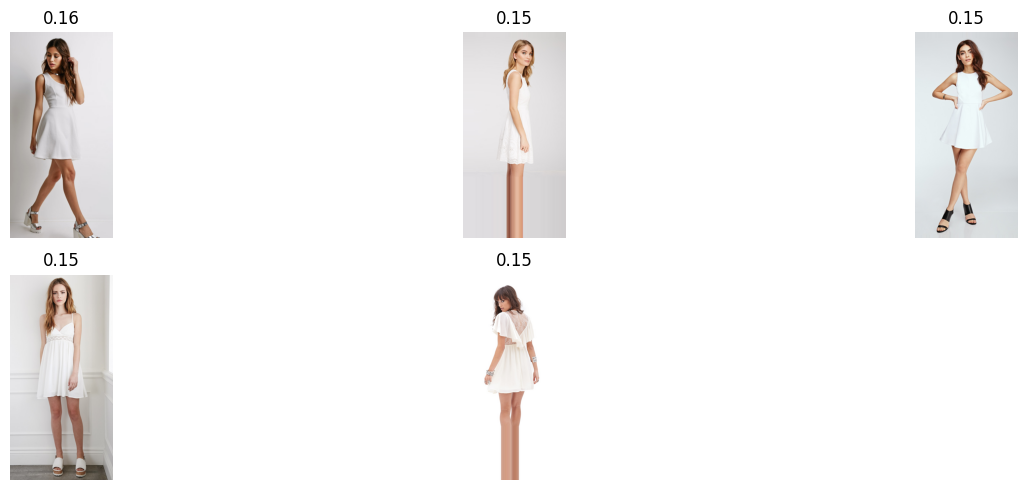

In [17]:
# ============================================================
# CELL 12: Helper Function to Display Images
# ============================================================
import matplotlib.pyplot as plt

def show_results(results, cols=3, figsize=(15, 5)):
    """
    Display retrieved images in a grid.
    
    Args:
        results: list of dicts with 'path' key (output of search functions)
        cols: number of columns in grid
        figsize: figure size for matplotlib
    """
    if not results:
        print("No results to display.")
        return

    rows = (len(results) + cols - 1) // cols
    plt.figure(figsize=figsize)

    for i, r in enumerate(results):
        try:
            img = Image.open(r['path']).convert("RGB")
            plt.subplot(rows, cols, i+1)
            plt.imshow(img)
            plt.axis('off')
            # Show final score on title
            plt.title(f"{r['final_score']:.2f}")
        except Exception as e:
            print(f"Error loading image {r['path']}: {e}")

    plt.tight_layout()
    plt.show()

# ============================================================
# CELL 13: Example Usage with Display
# ============================================================

# --- Image-to-image search (strict color match) ---
results = search_by_image(
    "/kaggle/input/datasets/abulkashemjunaid/lungipic/Amanat_Shah_lungi_LS-1141_121_1.jpg",
    k=5,
    filter_by_color=True,
    filter_by_category=False,
    alpha=0.6,
    verbose=True
)
show_results(results)

# --- Text query ---
results = search_by_text(
    "girl wearing white dress",
    k=5,
    alpha=0.5,
    verbose=True
)
show_results(results)